# Feed Forward Network con PyTorch

En este notebook se implementa una red neuronal feed forward para clasificacion multiclase sobre MNIST usando PyTorch

In [ ]:
import copy
import gzip
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, TensorDataset

SEED = 42
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

Available device: cuda


## 1. Carga y particion del dataset



In [10]:
def read_mnist_images(path):
    with gzip.open(path, "rb") as f:
        f.read(4)
        num_images = int.from_bytes(f.read(4), "big")
        rows = int.from_bytes(f.read(4), "big")
        cols = int.from_bytes(f.read(4), "big")
        buffer = f.read()
    return torch.frombuffer(bytearray(buffer), dtype=torch.uint8).clone().view(num_images, rows * cols).float() / 255.0


def read_mnist_labels(path):
    with gzip.open(path, "rb") as f:
        buffer = f.read()[8:]
    return torch.frombuffer(bytearray(buffer), dtype=torch.uint8).clone().long()


def build_mnist_datasets(data_dir, val_size=10000, seed=SEED):
    train_images = read_mnist_images(data_dir / "train-images-idx3-ubyte.gz")
    train_labels = read_mnist_labels(data_dir / "train-labels-idx1-ubyte.gz")
    test_images = read_mnist_images(data_dir / "t10k-images-idx3-ubyte.gz")
    test_labels = read_mnist_labels(data_dir / "t10k-labels-idx1-ubyte.gz")

    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(train_images), generator=generator)
    val_indices = indices[:val_size]
    train_indices = indices[val_size:]

    full_train = TensorDataset(train_images, train_labels)
    train_dataset = Subset(full_train, train_indices.tolist())
    val_dataset = Subset(full_train, val_indices.tolist())
    test_dataset = TensorDataset(test_images, test_labels)
    return train_dataset, val_dataset, test_dataset


data_dir = Path("../data/mnist").resolve()
train_dataset, val_dataset, test_dataset = build_mnist_datasets(data_dir)

print(f"Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 50000 | Validation: 10000 | Test: 10000


## 2. Definicion de la red neuronal

In [11]:
class FeedForwardNet(nn.Module):
    def __init__(self, hidden_dims):
        super().__init__()
        layers = []
        in_dim = 784
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers.append(nn.Linear(in_dim, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def make_optimizer(config, model):
    if config["optimizer"] == "Adam":
        return torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    return torch.optim.SGD(
        model.parameters(),
        lr=config["learning_rate"],
        momentum=config.get("momentum", 0.0),
    )

## 3. Funciones de entrenamiento, validacion y early stopping

In [ ]:
def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = total_correct = total_examples = 0

    with torch.no_grad():
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            batch_size = labels.size(0)

            total_loss += criterion(logits, labels).item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples


def should_early_stop(loss_history, patience, delta):
    if len(loss_history) <= patience:
        return False
    old_loss = loss_history[-patience - 1]
    new_loss = loss_history[-1]
    return abs(old_loss - new_loss) < delta and old_loss >= new_loss


def train_model(config, train_dataset, val_dataset):
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)

    model = FeedForwardNet(config["hidden_dims"]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(config, model)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    best_val_acc = 0.0
    best_epoch = 0
    val_loss_history = []

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0

        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(features)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)

        train_loss = total_loss / total_examples
        train_acc = total_correct / total_examples
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)
        val_loss_history.append(val_loss)

        if val_acc > best_val_acc or (val_acc == best_val_acc and val_loss < best_val_loss):
            best_state = copy.deepcopy(model.state_dict())
            best_val_loss = val_loss
            best_val_acc = val_acc
            best_epoch = epoch

        print(
            f"Epoch {epoch:02d} | "
            f"train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f} | val acc: {val_acc:.4f}"
        )

        if config.get("use_early_stopping", False) and should_early_stop(
            val_loss_history, config["patience"], config["delta"]
        ):
            print("early stopping activado (antes de que truene la gpu)")
            break

    model.load_state_dict(best_state)

    return model, {
        "name": config["name"],
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": best_val_acc,
        "batch_size": config["batch_size"],
    }

## 4. Entrenamiento de 3 redes neuronales distintas

Aqui se modifican varios hiperparametros: arquitectura, optimizador, mini batch, numero de epocas y learning rate.


In [17]:
experiments = [
    {
        "name": "mlp_1_hidden_adam",
        "hidden_dims": [128],
        "optimizer": "Adam",
        "batch_size": 256,
        "epochs": 6,
        "learning_rate": 1e-3,
        "use_early_stopping": True,
        "patience": 2,
        "delta": 5e-4,
    },
    {
        "name": "mlp_2_hidden_adam",
        "hidden_dims": [256, 128],
        "optimizer": "Adam",
        "batch_size": 256,
        "epochs": 8,
        "learning_rate": 8e-4,
        "use_early_stopping": True,
        "patience": 2,
        "delta": 5e-4,
    },
    {
        "name": "mlp_2_hidden_sgd",
        "hidden_dims": [512, 256],
        "optimizer": "SGD",
        "batch_size": 128,
        "epochs": 8,
        "learning_rate": 5e-2,
        "momentum": 0.9,
        "use_early_stopping": True,
        "patience": 3,
        "delta": 5e-4,
    },
]

results = []
best_model = None
best_result = None

for config in experiments:
    print("=" * 86)
    print(f"Running: {config['name']}")
    model, result = train_model(config, train_dataset, val_dataset)
    results.append(result)

    if best_result is None or result["best_val_acc"] > best_result["best_val_acc"] or (
        result["best_val_acc"] == best_result["best_val_acc"] and result["best_val_loss"] < best_result["best_val_loss"]
    ):
        best_result = result
        best_model = model

print("\nResumen")
for r in sorted(results, key=lambda x: (-x["best_val_acc"], x["best_val_loss"])):
    print(
        f"{r['name']:<22} "
        f"best epoch: {r['best_epoch']:<2} "
        f"val loss: {r['best_val_loss']:.4f} "
        f"val acc: {r['best_val_acc']:.4f}"
    )

print("\nMejor modelo:")
print(best_result)

Running: mlp_1_hidden_adam
Epoch 01 | train loss: 0.5693 | train acc: 0.8616 | val loss: 0.3010 | val acc: 0.9153
Epoch 02 | train loss: 0.2602 | train acc: 0.9267 | val loss: 0.2319 | val acc: 0.9340
Epoch 03 | train loss: 0.2017 | train acc: 0.9425 | val loss: 0.1914 | val acc: 0.9458
Epoch 04 | train loss: 0.1638 | train acc: 0.9530 | val loss: 0.1645 | val acc: 0.9516
Epoch 05 | train loss: 0.1368 | train acc: 0.9617 | val loss: 0.1447 | val acc: 0.9557
Epoch 06 | train loss: 0.1161 | train acc: 0.9674 | val loss: 0.1308 | val acc: 0.9601
Running: mlp_2_hidden_adam
Epoch 01 | train loss: 0.5348 | train acc: 0.8615 | val loss: 0.2716 | val acc: 0.9207
Epoch 02 | train loss: 0.2226 | train acc: 0.9354 | val loss: 0.1968 | val acc: 0.9388
Epoch 03 | train loss: 0.1549 | train acc: 0.9556 | val loss: 0.1427 | val acc: 0.9568
Epoch 04 | train loss: 0.1174 | train acc: 0.9664 | val loss: 0.1230 | val acc: 0.9622
Epoch 05 | train loss: 0.0940 | train acc: 0.9725 | val loss: 0.1031 | val a

## 5. Reporte de clasificacion sin librerias externas

Se genera la matriz de confusion, el accuracy global y las metricas por clase: precision, recall y F1.
Tambien se agrega una visualizacion con matplotlib de la matriz de confusion y una prediccion sobre una imagen de test.


Test loss: 0.0711
Test accuracy: 0.9799

Global accuracy: 0.9799

Class    Precision       Recall     F1-score    Support
-------------------------------------------------------
    0       0.9858       0.9888       0.9873        980
    1       0.9921       0.9921       0.9921       1135
    2       0.9595       0.9864       0.9728       1032
    3       0.9753       0.9772       0.9763       1010
    4       0.9796       0.9776       0.9786        982
    5       0.9766       0.9821       0.9793        892
    6       0.9905       0.9812       0.9858        958
    7       0.9870       0.9621       0.9744       1028
    8       0.9715       0.9784       0.9749        974
    9       0.9810       0.9722       0.9766       1009


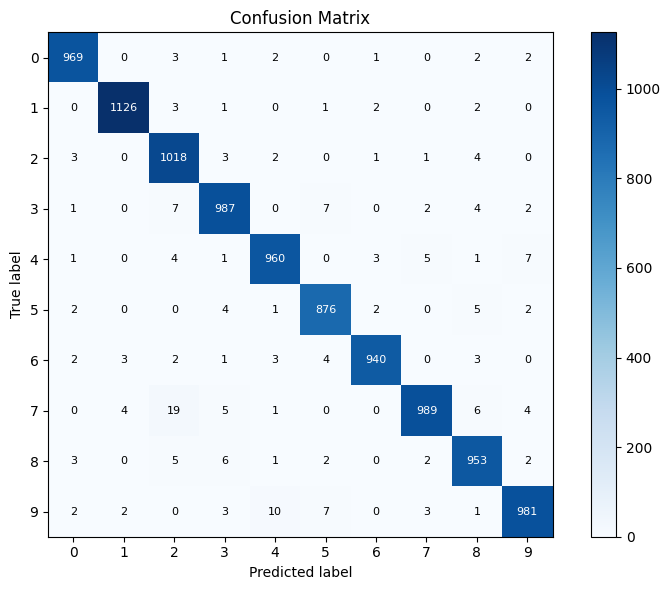

In [15]:
def collect_predictions(model, dataloader):
    model.eval()
    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            logits = model(features)
            preds = logits.argmax(dim=1).cpu()
            all_targets.append(labels)
            all_predictions.append(preds)

    return torch.cat(all_targets), torch.cat(all_predictions)


def build_confusion_matrix(targets, predictions, num_classes=10):
    cm = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for t, p in zip(targets, predictions):
        cm[int(t), int(p)] += 1
    return cm


def classification_report_from_confusion_matrix(cm):
    tp = cm.diag().float()
    support = cm.sum(dim=1).float()
    predicted = cm.sum(dim=0).float()

    accuracy = tp.sum() / cm.sum().float()
    precision = tp / predicted.clamp_min(1.0)
    recall = tp / support.clamp_min(1.0)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)

    return accuracy.item(), precision, recall, f1, support


def plot_confusion_matrix(cm):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm.numpy(), cmap="Blues")
    plt.colorbar()
    plt.xticks(range(10))
    plt.yticks(range(10))
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")

    threshold = cm.max().item() / 2
    for i in range(10):
        for j in range(10):
            color = "white" if cm[i, j] > threshold else "black"
            plt.text(j, i, int(cm[i, j]), ha="center", va="center", color=color, fontsize=8)

    plt.tight_layout()
    plt.show()


criterion = nn.CrossEntropyLoss()
test_loader = DataLoader(test_dataset, batch_size=best_result["batch_size"], shuffle=False)
test_loss, test_acc = evaluate_model(best_model, test_loader, criterion)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

targets, predictions = collect_predictions(best_model, test_loader)
cm = build_confusion_matrix(targets, predictions)
global_accuracy, precision, recall, f1, support = classification_report_from_confusion_matrix(cm)

print(f"\nGlobal accuracy: {global_accuracy:.4f}\n")

header = f"{'Class':>5} {'Precision':>12} {'Recall':>12} {'F1-score':>12} {'Support':>10}"
print(header)
print("-" * len(header))
for i in range(10):
    print(
        f"{i:>5} "
        f"{precision[i].item():>12.4f} "
        f"{recall[i].item():>12.4f} "
        f"{f1[i].item():>12.4f} "
        f"{int(support[i].item()):>10}"
    )

plot_confusion_matrix(cm)

## 7. Reflexiones personales

La actividad fue un buen recordatorio de cómo trabajar con redes neuronles y del proceso de entrenamiento usando batches, funciones de pérdida y optimizadores. También me sirvió para aprender a usar pytorch, ya que en el curso pasado de deep learning trabajé unicamente con tensorflow. Tambien al probar diferentes configuraciones de la red pude ver cómo cambios en la arquitectura, el optimizador o el tamaño del batch pueden afectar el desempeño del modelo.

